# BERTopic hashtag modelling pipeline
**Project:** XXX  
**Authors:** XXX

**Lastest version:** 23-4-2026

## Notebook overview
This notebook uses preprocessed documents of hashtag sequences from 5.3 million unique TikTok videos to topic model with BERTopic.

**⚠️ Runtime note:** Running specific cells on different/optimized hardware is recommended. After each step, intermediary checkpoint files are created as output so long-running cells can be skipped. Warnings for long-running cells are marked.

**🔁 Reproducibility note:** Results may vary slightly between runs and hardware environments.

______________________
# I - Importing packages & helper functions

In [ ]:
# ────────────────────────────────────────────────
# Standard Library
# ────────────────────────────────────────────────
import gc
import os
import pickle
import requests
import time
from itertools import product
from pathlib import Path
from time import sleep

# ────────────────────────────────────────────────
# Third-Party Libraries
# ────────────────────────────────────────────────
import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import numpy.core.numeric
import sys

sys.modules["numpy._core.numeric"] = numpy.core.numeric
import pandas as pd
import torch
from tqdm.auto import tqdm

# ────────────────────────────────────────────────
# Scikit-learn
# ────────────────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import silhouette_score

# ────────────────────────────────────────────────
# UMAP & Embeddings
# ────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

# ────────────────────────────────────────────────
# BERTopic
# ────────────────────────────────────────────────
from bertopic import BERTopic

# Helper function for safely loading checkpoint pickle files
def safe_load_checkpoint(checkpoint_file):
    """Safely load checkpoint, handling corrupted/incomplete files."""
    if not os.path.exists(checkpoint_file):
        return None
    try:
        with open(checkpoint_file, 'rb') as f:
            checkpoint = pickle.load(f)
        return checkpoint
    except (EOFError, pickle.UnpicklingError):
        print("⚠️ Corrupted or incomplete checkpoint detected. Starting fresh...")
        os.remove(checkpoint_file)
        return None

# Helper function to access locally stored embedding models
def get_local_model_path(repo_id):
    cache_base = Path.home() / ".cache" / "huggingface" / "hub"
    cache_name = f"models--{repo_id.replace('/', '--')}"
    return cache_base / cache_name / "snapshots" / "main"

# ── Project config ───────────────────────────────────────────────────────────
from config import *

_____________________
# II - Preparing BERTopic

Steps:
1. Optimizing environment parameters for computational efficiency
2. Loading documents `docs_bert` that were created in `1_BERTopic data preparation`
3. Creating a random sub-set of the data for evaluating sentence transformer models and grid search parameter optimization

In [2]:
# Reduce thread contention between libraries
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

Loading input documents.

In [ ]:
with open(FINAL_DOCS_PATH, "rb") as f:
    docs_bert = pickle.load(f)

print(f"Nr. of documents: {len(docs_bert)}")

5332704


Document stats:

In [4]:
# Document summary
#words_bert = list(chain.from_iterable(doc.split() for doc in docs_bert))
#total_words_bert = len(words_bert)
#unique_words_bert = len(set(words_bert))

#print(f"Nr. of documents: {len(docs_bert)}")
#print(f"  Total words: {total_words_bert:,}")
#print(f"  Unique words: {unique_words_bert:,}")

Creating a random sub-set of the data for later steps.

In [5]:
# Random seed
np.random.seed(1)

# 50,000 random documents
sample_idx = np.random.choice(len(docs_bert), 50_000, replace=False)
docs_sample = [docs_bert[i] for i in sample_idx]

____________
# III - Running BERTopic

## Step 0: Choosing an embedding model (optional)
Run this section first to pick an embedding model that:

- Runs fast enough
- Produces stable embeddings (consistent cosine distances)
- Fits in memory
- Gives meaningful clusters in BERTopic with default settings, based on silhouette score, topic diversity and qualitative output inspection

In [6]:
# Check if GPU is available
# print(torch.cuda.is_available())  # should be True
# print(torch.cuda.device_count())  # number of GPUs detected
# print(torch.cuda.get_device_name(0))  # name of your GPU

Ten embedding models are compared on a subset of our data using **BERTopic** with default settings to identify the best fit.

| Model | Source |
|:------|:--------|
| all-MiniLM-L6-v2 | [Hugging Face](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2) |
| all-MiniLM-L12-v2 | [Hugging Face](https://huggingface.co/sentence-transformers/all-MiniLM-L12-v2) |
| all-mpnet-base-v2 | [SBERT Docs](https://www.sbert.net/docs/sentence_transformer/pretrained_models.html) |
| paraphrase-MiniLM-L6-v2 | [Hugging Face](https://huggingface.co/sentence-transformers/paraphrase-MiniLM-L6-v2) |
| multi-qa-MiniLM-L6-cos-v1 | [Hugging Face](https://huggingface.co/sentence-transformers/multi-qa-MiniLM-L6-cos-v1) |
| paraphrase-multilingual-MiniLM-L12-v2 | [Hugging Face](https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2) |
| bge-small-en-v1.5 | [BAAI](https://huggingface.co/BAAI/bge-small-en-v1.5) |
| bge-base-en-v1.5 | [BAAI](https://huggingface.co/BAAI/bge-base-en-v1.5) |
| e5-small-v2 | [Intfloat](https://huggingface.co/intfloat/e5-small-v2) |
| e5-base-v2 | [Intfloat](https://huggingface.co/intfloat/e5-base-v2) |


In [7]:
# Embedding models
test_models = [
    # Baseline models
    "sentence-transformers/all-MiniLM-L6-v2",  # fast baseline
    "sentence-transformers/all-MiniLM-L12-v2", # deeper, slower
    "sentence-transformers/all-mpnet-base-v2", # better quality

    # Specialized for short text & social media
    "sentence-transformers/paraphrase-MiniLM-L6-v2",  # optimized for short text
    "sentence-transformers/multi-qa-MiniLM-L6-cos-v1",  # query-focused
    
    # Multilingual
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",  # 50+ languages
    
    # Modern/larger models (if quality > speed)
    "BAAI/bge-small-en-v1.5",  # strong recent model, small size
    "BAAI/bge-base-en-v1.5",   # better quality version
    
    # E5 family (state-of-art open models)
    "intfloat/e5-small-v2",    # prefix with "query:" or "passage:"
    "intfloat/e5-base-v2",     # stronger version
]

In [8]:
# Download embedding model 
def download_model_files(repo_id, cache_base=None, verbose=False, max_retries=3):
    """
    Robust downloader for sentence-transformer models.
    Downloads main config files, model weights, and numbered submodule directories (e.g., 0_Transformer/).
    Automatically retries large files and checks for both 'model.safetensors' and 'pytorch_model.bin'.
    """
    if cache_base is None:
        cache_base = Path.home() / ".cache" / "huggingface" / "hub"

    cache_name = f"models--{repo_id.replace('/', '--')}"
    snapshot_dir = cache_base / cache_name / "snapshots" / "main"
    snapshot_dir.mkdir(parents=True, exist_ok=True)

    base_url = f"https://huggingface.co/{repo_id}/resolve/main/"

    # Core files including model weights
    base_files = [
        "model.safetensors", "pytorch_model.bin", "config.json", "tokenizer.json",
        "tokenizer_config.json", "vocab.txt", "special_tokens_map.json",
        "sentence_bert_config.json", "config_sentence_transformers.json",
        "modules.json",
    ]

    success = 0
    failed_files = []

    def download_file(url, output_path):
        for attempt in range(max_retries):
            try:
                with requests.get(url, stream=True, timeout=120) as r:
                    if r.status_code == 404:
                        return False
                    r.raise_for_status()
                    with open(output_path, "wb") as f:
                        for chunk in r.iter_content(chunk_size=8192):
                            if chunk:
                                f.write(chunk)
                return True
            except Exception as e:
                if verbose:
                    print(f"⚠️ Attempt {attempt+1} failed for {output_path.name}: {e}")
                sleep(5)
        return False

    # Download top-level files
    for filename in base_files:
        output_path = snapshot_dir / filename
        if output_path.exists() and output_path.stat().st_size > 0:
            success += 1
            continue
        url = base_url + filename
        if download_file(url, output_path):
            success += 1
        else:
            failed_files.append(filename)

    # Download numbered submodules (0_Transformer, 1_Pooling, etc.)
    for i in range(6):
        for module_type in ["Transformer", "Pooling", "Dense", "Normalization"]:
            subdir = f"{i}_{module_type}"
            subdir_url = base_url + subdir + "/config.json"
            subdir_path = snapshot_dir / subdir
            subdir_path.mkdir(exist_ok=True)
            cfg_file = subdir_path / "config.json"

            if cfg_file.exists():
                continue

            if download_file(subdir_url, cfg_file):
                success += 1

    if verbose:
        print(f"✅ {repo_id}: {success} files downloaded into {snapshot_dir}")
        if failed_files:
            print(f"⚠️ Failed to download: {failed_files}")

    return success > 0

if __name__ == "__main__":
    # List of all models to download (loaded above)
    models_to_download = test_models

    print("🚀 Starting bulk model download...")
    cache_dir = Path.home() / ".cache" / "huggingface" / "hub"
    print(f"📁 Cache directory: {cache_dir}")
    print(f"📊 Models to download: {len(models_to_download)}\n")

    successful, failed = 0, []

    for model in tqdm(models_to_download, desc="📦 Downloading models"):
        try:
            ok = download_model_files(model, verbose=False)
            if ok:
                successful += 1
            else:
                failed.append(model)
        except KeyboardInterrupt:
            print("\n⚠️ Interrupted by user — progress saved.")
            break
        except Exception:
            failed.append(model)

    print("\n" + "=" * 60)
    print("📊 DOWNLOAD SUMMARY")
    print("=" * 60)
    print(f"✅ Successful: {successful}/{len(models_to_download)}")
    if failed:
        print(f"❌ Failed: {len(failed)}")
        for m in failed:
            print(f"   - {m}")

🚀 Starting bulk model download...
📁 Cache directory: C:\Users\IVONDEN\.cache\huggingface\hub
📊 Models to download: 10



📦 Downloading models:   0%|          | 0/10 [00:00<?, ?it/s]


📊 DOWNLOAD SUMMARY
✅ Successful: 10/10


### Comparing different embedding models

Topic Diversity = unique words / total words

* A score of 1.0 means every word across all topics is unique: topics are perfectly distinct from each other
* A score close to 0 means topics are all sharing the same vocabulary: they're redundant.

In [9]:
# Computation for topic diversity
def compute_topic_diversity(topic_model, topk=10):
    topics = topic_model.get_topics()
    # Use a set directly instead of extending a list then converting
    all_words = [
        word
        for topic_id, topic_words in topics.items()
        if topic_id != -1 # Exclude outlier topic
        for word, _ in topic_words[:topk]
    ]
    return len(set(all_words)) / len(all_words) if all_words else 0

# Compare our test_models with BERTopic on default settings 
def evaluate_sentence_transformers(
    docs,
    model_names,
    batch_size=128,
    verbose=True,
    umap_random_state=42,        # explicit control seed for reproducibility
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    if verbose:
        print("Using device:", device)

    # Fix UMAP/HDBSCAN for reproducibility across runs
    umap_model = UMAP(random_state=umap_random_state, n_components=5, metric="cosine")
    hdbscan_model = HDBSCAN(min_cluster_size=15, prediction_data=True)

    results = []

    for model_name in model_names:
        if verbose:
            if torch.cuda.is_available():
                print(f"\nGPU Memory before {model_name}: {torch.cuda.memory_allocated()/1e9:.2f} GB")
            print(f"\n🔹 Evaluating {model_name}...")

        start_time = time.time()

        try:
            local_path = get_local_model_path(model_name)
            load_path = str(local_path) if local_path.exists() else model_name
            model = SentenceTransformer(load_path, device=device)
        except Exception as e:
            print(f"⚠️ Error with {model_name}, falling back to CPU: {e}")
            model = SentenceTransformer(model_name, device="cpu")

        embeddings = model.encode(
            docs,
            batch_size=batch_size,
            show_progress_bar=verbose,
            device=device
        )

        topic_model = BERTopic(
            umap_model=umap_model,
            hdbscan_model=hdbscan_model,
            embedding_model=None,
            verbose=False
        )
        topics, _ = topic_model.fit_transform(docs, embeddings)

        # Metrics
        # exclude outliers from silhouette score calculation
        non_outlier_mask = np.array([t != -1 for t in topics])
        topics_arr = np.array(topics)
        embeddings_filtered = embeddings[non_outlier_mask]
        topics_filtered = topics_arr[non_outlier_mask]

        unique_topics = len(set(topics_filtered))
        silhouette = silhouette_score(embeddings_filtered, topics_filtered) if unique_topics > 1 else -1
        diversity = compute_topic_diversity(topic_model)
        outlier_proportion = round((~non_outlier_mask).sum() / len(topics), 4)
        duration = round(time.time() - start_time, 2)

        # Print example topics
        if verbose:
            topic_info = topic_model.get_topic_info()
            sample_topics = topic_info[topic_info["Topic"] != -1].head(5)
            print(f"\n  📋 Sample topics (outliers: {outlier_proportion:.1%}):")
            for _, row in sample_topics.iterrows():
                words = ", ".join([w for w, _ in topic_model.get_topic(row["Topic"])[:8]])
                print(f"     Topic {row['Topic']:>3} ({row['Count']:>5} docs): {words}")
            print(f"✅ Finished {model_name}: topics={unique_topics}, silhouette={silhouette:.4f}, "
                  f"diversity={diversity:.4f}, outliers={outlier_proportion:.1%}, time={duration}s")

        results.append({
            "model": model_name,
            "num_topics": unique_topics,
            "silhouette": silhouette,
            "topic_diversity": diversity,
            "outlier_proportion": outlier_proportion,
            "time_seconds": duration
        })

        # Clean memory
        del model, embeddings, topic_model
        torch.cuda.empty_cache()
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
            torch.cuda.ipc_collect()

    return pd.DataFrame(results).sort_values(by="silhouette", ascending=False)

⚠️ Run time may vary for different devices. GPU usage is advised.

In [10]:
# Run embedding test
# embedtest_results_df = evaluate_sentence_transformers(docs_sample, test_models, batch_size=128)

In [11]:
# print("\nFinal Results:")
# embedtest_results_df

In [12]:
# Save results
# embedtest_results_df.to_pickle(EMBED_TEST_PATH) 

## Step 1: Creating Embeddings of the entire data

Selecting the best model based on Step 0:

In [34]:
# Reload if needed
embedtest_results_df = pd.read_pickle(EMBED_TEST_PATH) 

best_model_name = embedtest_results_df.iloc[0]["model"]

print("🏆 Best embedding model:", best_model_name)

🏆 Best embedding model: sentence-transformers/all-MiniLM-L12-v2


In [14]:
# Function to compute word embeddings with save checkpointing
def encode_with_checkpointing(
    docs,
    model_name,
    batch_size=512,
    checkpoint_dir=TOPIC_MODELLING_FILES_DIR, 
    checkpoint_every=5000,
    device=None,
    num_workers=4,
    use_fp16=True
):
    """
    Optimized encoding with checkpointing, recovery, and performance tuning.

    Args:
        docs: List of text documents to embed
        model_name: SentenceTransformer model name
        batch_size: Batch size for encoding
        checkpoint_dir: Directory to save checkpoints
        checkpoint_every: Save checkpoint after this many docs
        device: 'cuda', 'cpu', or None for auto
        num_workers: Data loading workers
        use_fp16: Use half precision for speed (GPU only)

    Returns:
        final_embeddings.npy: Numpy array of embeddings
    """
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_file = os.path.join(checkpoint_dir, "checkpoint_embeddings.pkl")
    final_file = os.path.join(checkpoint_dir, "final_embeddings.npy")

    # Load existing final embeddings if available
    if os.path.exists(final_file):
        print("✅ Loading existing final embeddings...")
        return np.load(final_file)

    # Auto-detect device
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # Initialize SentenceTransformer model
    try:
            local_path = get_local_model_path(model_name)
            if local_path.exists():
                embedder = SentenceTransformer(str(local_path), device=device)
            else:
                embedder = SentenceTransformer(model_name, device=device)
    except Exception as e:
            print(f"⚠️ Error with {model_name}, falling back to CPU: {e}")
            embedder = SentenceTransformer(model_name, device="cpu")

    # Use GPU if available
    if device == "cuda" and use_fp16:
        embedder.half()
        print("FP16 mixed precision enabled")

    if hasattr(torch, "compile") and device == "cuda":
        try:
            embedder = torch.compile(embedder)
            print("Model compiled with PyTorch 2.0+ optimization")
        except Exception:
            pass

    # Load checkpoint safely
    checkpoint = safe_load_checkpoint(checkpoint_file)
    start_idx, embeddings_list, all_embeddings = 0, [], None

    if checkpoint:
        start_idx = checkpoint.get("last_idx", 0)
        embeddings_list = checkpoint.get("embeddings", [])
        if "partial_array" in checkpoint and checkpoint["partial_array"] is not None:
            all_embeddings = checkpoint["partial_array"]
        print(f"Resuming from document {start_idx}/{len(docs)}")

    # Preallocate memory
    use_preallocated = False
    if all_embeddings is None and len(docs) < 10_000_000:
        try:
            embedding_dim = embedder.get_sentence_embedding_dimension()
            all_embeddings = np.empty((len(docs), embedding_dim), dtype=np.float32)
            use_preallocated = True
            print(f"Pre-allocated embedding array: {all_embeddings.shape}")
        except Exception:
            print("Memory pre-allocation skipped (insufficient memory).")

    # Main encoding loop
    try:
        batches = range(start_idx, len(docs), batch_size)
        pbar = tqdm(
            batches,
            desc="Encoding",
            initial=start_idx // batch_size,
            total=(len(docs) + batch_size - 1) // batch_size,
        )

        for i in pbar:
            batch = docs[i:min(i + batch_size, len(docs))]

            # Encode batch efficiently
            with torch.no_grad():
                batch_embeddings = embedder.encode(
                    batch,
                    batch_size=batch_size,
                    show_progress_bar=False,
                    convert_to_numpy=True,
                    normalize_embeddings=False, # Set to false - BERTopic / UMAP handles this
                    device=device,
                )

            # Store embeddings
            if use_preallocated:
                end_idx = min(i + batch_size, len(docs))
                all_embeddings[i:end_idx] = batch_embeddings
            else:
                embeddings_list.append(batch_embeddings)

            # Progress update
            if i > start_idx and pbar.format_dict['elapsed'] > 0:
                docs_per_sec = (i - start_idx) / pbar.format_dict['elapsed']
                pbar.set_postfix({'docs/sec': f'{docs_per_sec:.0f}'})

            # Periodic checkpointing
            if (i + batch_size - start_idx) % checkpoint_every == 0 or i + batch_size >= len(docs):
                checkpoint = {
                    'last_idx': min(i + batch_size, len(docs)),
                    'embeddings': embeddings_list if not use_preallocated else None,
                    'partial_array': all_embeddings[:min(i + batch_size, len(docs))] if use_preallocated else None
                }
                with open(checkpoint_file, 'wb') as f:
                    pickle.dump(checkpoint, f, protocol=pickle.HIGHEST_PROTOCOL)

    except KeyboardInterrupt:
        print("\n⏸ Interrupted! Saving progress...")
        checkpoint = {
            'last_idx': i,
            'embeddings': embeddings_list if not use_preallocated else None,
            'partial_array': all_embeddings[:i] if use_preallocated else None,
        }
        with open(checkpoint_file, 'wb') as f:
            pickle.dump(checkpoint, f, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Checkpoint saved at document {i}. Restart to resume.")
        raise

    # Combine embeddings
    embeddings = all_embeddings if use_preallocated else np.vstack(embeddings_list)

    # Save final embeddings
    np.save(final_file, embeddings)
    if os.path.exists(checkpoint_file):
        os.remove(checkpoint_file)

    print(f"✅ Encoding complete! Shape: {embeddings.shape}")
    return embeddings

### 🧠 `encode_with_checkpointing`

| Argument | Type | Description |
|----------|------|-------------|
| `docs` | `list[str]` |  `docs_bert` (*N* = 5332704). A list of pre-cleaned hashtags. |
| `model_name` | `str` | The name or path of the embedding model to use. |
| `batch_size` | `int`, default = `512` | Number of documents processed in parallel during embedding. Larger batches improve speed but require more GPU memory. |
| `checkpoint_dir` | `str` or `Path` | Directory where intermediate embedding checkpoints are saved, defined above under `CHECKPOINT_DIR_EMBEDDINGS`.|
| `checkpoint_every` | `int`, default = `5000` | Number of documents after which to save a checkpoint. Useful for very large corpora to avoid re-encoding everything on restart. |
| `device` | `str`, default = `None` | Device to run the model on: `"cuda"` for GPU or `"cpu"`. If `None`, automatically uses GPU if available. |
| `num_workers` | `int`, default = `4` | Number of CPU threads for preprocessing and data loading. Increase for faster speed with large datasets. |
| `use_fp16` | `bool`, default = `True` | Whether to use 16-bit floating-point precision during inference. Speeds up GPU inference while reducing memory usage. Set `False` if GPU doesn’t support mixed precision or if you encounter NaNs. |

**⚠️ The cell below will require a long runtime which varies per hardware (ca. 9 hours with GPU enabled).**

In [15]:
# embeddings = encode_with_checkpointing(docs_bert, model_name=best_model_name)

## Step 2: Sample sensitivity analysis & Gridsearch for UMAP/HDBSCAN Parameters

In [ ]:
# Reload embeddings
embeddings = np.load(EMBEDDINGS_PATH, mmap_mode="r")

# Check shape
print("Type:", type(embeddings))
print("Shape:", getattr(embeddings, "shape", None))

In [ ]:
# Silhouette score on a random sample, excluding outlier topic -1.
def _silhouette_on_sample(
    embeddings: np.ndarray,
    topics: np.ndarray,
    sample_size: int = 50_000,
    random_seed: int = 42,
) -> float:
    rng  = np.random.default_rng(random_seed)
    idx  = rng.choice(len(topics), size=min(sample_size, len(topics)), replace=False)
    t, e = topics[idx], embeddings[idx]
    mask = t != -1
    t, e = t[mask], e[mask]
    if len(np.unique(t)) < 2 or len(t) < 2:
        return -1.0
    return float(silhouette_score(e, t))

# Sample sensitivity analysis
def run_sample_sensitivity(
    docs: list,
    embeddings: np.ndarray,
    sample_sizes: list,
    umap_params: dict,
    hdbscan_params: dict,
    silhouette_sample: int = 50_000,
    n_sample_topics: int = 5,      # topics to print per size
    n_sample_docs: int = 3,        # documents to print per topic
    random_seed: int = 42,
    save_path=None,
) -> pd.DataFrame:
    """
    Fit BERTopic at each sample size and record quality metrics + qualitative output.

    Parameters
    ----------
    docs              : Full document list.
    embeddings        : Full embeddings array (same order as docs).
    sample_sizes      : List of training sample sizes to test.
    umap_params       : Fixed UMAP kwargs (n_neighbors, n_components, min_dist).
    hdbscan_params    : Fixed HDBSCAN kwargs (min_cluster_size, min_samples).
    silhouette_sample : Max docs used to compute silhouette score.
    n_sample_topics   : Number of topics to print for qualitative inspection.
    n_sample_docs     : Number of sample documents to print per topic.
    random_seed       : For reproducibility.
    save_path         : If given, save results DataFrame as CSV.
    """
    rng     = np.random.default_rng(random_seed)
    results = []

    for n in sample_sizes:
        print(f"\n{'='*60}")
        print(f"Sample size: {n:,}")
        print(f"{'='*60}")

        idx    = rng.choice(len(docs), size=min(n, len(docs)), replace=False)
        s_docs = [docs[i] for i in idx]
        s_embs = embeddings[idx]

        tm = BERTopic(
            embedding_model=None,
            umap_model=UMAP(
                **umap_params,
                metric="cosine",
                random_state=random_seed,
                low_memory=True,
                n_jobs=-1,
            ),
            hdbscan_model=HDBSCAN(
                **hdbscan_params,
                metric="euclidean",
                cluster_selection_method="eom",
                core_dist_n_jobs=-1,
                prediction_data=False,
            ),
            vectorizer_model=CountVectorizer(
                ngram_range=(1, 1), stop_words="english",
                max_features=10_000, min_df=1,
            ),
            calculate_probabilities=False,
            verbose=False,
        )

        # ── Fit & time ────────────────────────────────────────────────────────
        t0         = time.time()
        topics, _  = tm.fit_transform(s_docs, s_embs)
        elapsed    = time.time() - t0
        topics_arr = np.array(topics)

        # ── Quantitative metrics ──────────────────────────────────────────────
        n_topics    = len(np.unique(topics_arr[topics_arr != -1]))
        outlier_pct = (topics_arr == -1).mean() * 100
        sil         = _silhouette_on_sample(
            s_embs, topics_arr,
            sample_size=silhouette_sample,
            random_seed=random_seed,
        )
        diversity   = compute_topic_diversity(tm)
        docs_per_s  = n / elapsed

        print(f"  Topics:      {n_topics}")
        print(f"  Outliers:    {outlier_pct:.1f}%")
        print(f"  Silhouette:  {sil:.4f}")
        print(f"  Diversity:   {diversity:.4f}")
        print(f"  Time:        {elapsed:.1f}s  ({docs_per_s:.0f} docs/s)")

        # ── Qualitative inspection ────────────────────────────────────────────
        topic_info = tm.get_topic_info()
        topic_info = topic_info[topic_info["Topic"] != -1].head(n_sample_topics)

        print(f"\n  Sample topics (top {n_sample_topics} by size):")
        print(f"  {'-'*55}")
        for _, row in topic_info.iterrows():
            words    = ", ".join(w for w, _ in tm.get_topic(row["Topic"])[:8])
            doc_idxs = np.where(topics_arr == row["Topic"])[0]
            samples  = [s_docs[i] for i in doc_idxs[:n_sample_docs]]

            print(f"  Topic {row['Topic']:>3} ({row['Count']:>5} docs): {words}")
            for doc in samples:
                print(f"    → {doc}")

        results.append({
            "sample_size":  n,
            "n_topics":     n_topics,
            "outlier_pct":  round(outlier_pct, 2),
            "silhouette":   round(sil, 4),
            "diversity":    round(diversity, 4),
            "time_seconds": round(elapsed, 1),
            "docs_per_sec": round(docs_per_s, 0),
        })

        del tm
        gc.collect() # clean memory

    df = pd.DataFrame(results)
    if save_path:
        df.to_csv(save_path, index=False)
        print(f"\n💾 Saved to {save_path}")
    return df

In [27]:
# Fixed parameters for the sensitivity test - use a reasonable mid-range setting
SENSITIVITY_UMAP_PARAMS = {
    "n_neighbors": 15,
    "n_components": 10,
    "min_dist": 0.1,
    "init": "random",   # avoids spectral initialisation memory spike
}
SENSITIVITY_HDBSCAN_PARAMS = {"min_cluster_size": 30, "min_samples": 25}

# Test different sample sizes
SAMPLE_SIZES = [25_000, 50_000, 75_000, 100_000, 200_000]

In [ ]:
# ⚠️ Runtime scales with sample sizes
sensitivity_df = run_sample_sensitivity(
    docs=docs_bert,
    embeddings=embeddings,
    sample_sizes=SAMPLE_SIZES,
    umap_params=SENSITIVITY_UMAP_PARAMS,
    hdbscan_params=SENSITIVITY_HDBSCAN_PARAMS,
    save_path=SAMPLE_SENSITIVITY_PATH,
)
sensitivity_df


Sample size: 25,000
  Topics:      152
  Outliers:    38.0%
  Silhouette:  0.0894
  Diversity:   0.9526
  Time:        22.3s  (1119 docs/s)

  Sample topics (top 5 by size):
  -------------------------------------------------------
  Topic   0 (  655 docs): football, soccer, fifa, footballtiktok, ronaldo, futbol, messi, premierleague
    → ancelotti laliga benzema football soccer realmadrid valverde rayovallecano halamadrid rmfc
    → soccer premierleague manchestercity
    → loveisland dailymail jordanhames england manutd manchesterunited mainoo ufc ggmu
  Topic   1 (  415 docs): music, spotify, singing, newmusic, cover, piano, singer, guitar
    → spotify spotifyspeduppaudios audio lyrics
    → myplaylist555 songs lyricsvideo americahasaproblem music lyrics
    → angrymusic heavymusic breakdown
  Topic   2 (  409 docs): gymtok, gym, fitness, workout, bodybuilding, fittok, gymgirl, motivation
    → edrec0very bedrecoveryjourney fitnessjourney abcxyz bedrecoverytips momentsthataltered

,sample_size,n_topics,outlier_pct,silhouette,diversity,time_seconds,docs_per_sec
0,25000,152,37.96,0.0894,0.9526,22.3,1119.0
1,50000,267,34.00,0.0786,0.9172,52.2,958.0
2,75000,421,34.78,0.0829,0.8694,86.3,869.0
3,100000,551,33.93,0.0815,0.8160,121.7,822.0
4,200000,1004,35.86,0.0857,0.6575,397.4,503.0


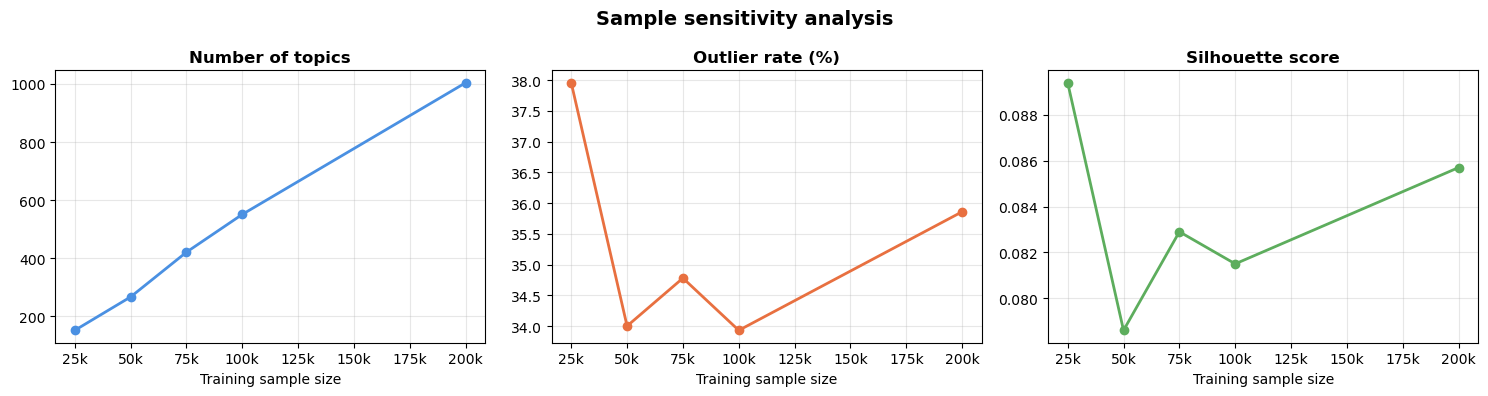

In [29]:
# Reload if needed
# sensitivity_df = pd.read_csv(SAMPLE_SENSITIVITY_PATH)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title, color in [
    (axes[0], "n_topics",    "Number of topics",   "#4A90E2"),
    (axes[1], "outlier_pct", "Outlier rate (%)",   "#E87040"),
    (axes[2], "silhouette",  "Silhouette score",   "#5DAD5D"),
]:
    ax.plot(sensitivity_df["sample_size"], sensitivity_df[col],
            marker="o", linewidth=2, color=color)
    ax.set_xlabel("Training sample size")
    ax.set_title(title, fontweight="bold")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
    ax.grid(alpha=0.3)

fig.suptitle("Sample sensitivity analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(TOPIC_MODELLING_FILES_DIR / "sample_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

### BERTopic grid search space:

A grid search is used to identify optimal parameters before scaling to the full data.

Definitions of the parameters are from __[Grootendorst (2025)](https://maartengr.github.io/BERTopic/getting_started/parameter%20tuning/parametertuning.html#n_neighbors)__.

#### UMAP parameter selection & justification

##### `n_neighbors`

The number of neighboring sample points used when making the manifold approximation. Increasing this value results in a more global view/larger clusters being created of the embedding structure whilst smaller values result in a more local view ([McInnes, Healy, & Melville, 2018](https://arxiv.org/abs/1802.03426)).

- `10` captures local structures, i.e., groups videos together with nearly identical hashtag combinations
- `15` is the UMAP default recommendation that balances local vs. global patterns, working well for medium-sized granularity 
- `30` captures broader patterns to connect videos across wider semantic spaces


##### `n_components` 

Refers to the dimensionality of the embeddings after reducing them. Lowering/increasing the value influences the quality of embeddings but has a large effect on the performance of HBDSCAN. If increased too much, HDBSCAN will have a hard time clustering the high-dimensional embeddings. Lowering it too much and too little information in the resulting embeddings are available to create proper clusters. If increased, it is recommended to use a metric for HDBSCAN that works well in high dimensional data, and it will increase runtime ([Grootendorst, 2022](https://arxiv.org/abs/2203.05794); [McInnes et al., 2018](https://arxiv.org/abs/1802.03426)).

- `5` for minimal dimensionality, assumes hashtag semantic space is simple with few core themes and is fast
- `10` for moderate complexity, allows for more nuanced topic distinctions
- `15` for high dimensionality, to preserve maximum information from embeddings and catching subtle differences between similar hashtags

##### `min_dist`

The minimum distance between points in UMAP space. 0 -> more compact clusters. Increase if clusters collapse too tightly, decrease to tighten clusters ([McInnes et al., 2018](https://arxiv.org/abs/1802.03426)).

- `0.0` for tightest clusters
- `0.1` slightly looser, striking a good balance for overlapping hashtag communities
- `0.3` for loose clusters to maintain a more global structure if hashtag categories have fuzzy boundaries (e.g., #fitness overlaps with #health, #workout etc.)

#### HDBSCAN parameter selection & justification

##### `min_cluster_size` 

Controls the minimum size of a cluster (how many documents are needed to generate a cluster) and thereby the number of clusters that will be generated. 10 is the default value, increasing it results in fewer clusters but of larger size, whereas decreasing it results in more micro clusters being generated. It is advised to increase this value rather than decreasing it. ([Grootendorst, 2025](https://maartengr.github.io/BERTopic/getting_started/parameter%20tuning/parametertuning.html#n_neighbors); [McInnes & Healy, 2017](https://arxiv.org/abs/1705.07321)).

- `10` allows for micro-topics to capture niche communities, finding care but coherent hashtag patterns
- `30` filters out the tiniest niches, focusing on slightly more popular hashtags to reduce noise while keeping specificity
- `50` finds established hashtag trends that appear consistently
- `100` captures major themes, focusing on dominant patterns while reducing total topic count

##### `min_samples` 

Controls  the number of outliers generated, and is automatically set to `min_cluster_size`. Setting this value significantly lower than `min_cluster_size` might help reduce the amount of noise, but outliers are to be expected and forcing the output to have no outliers may not properly represent the data ([Campello, Moulavi, & Sander, 2013](https://link.springer.com/chapter/10.1007/978-3-642-37456-2_14#citeas)).

- `15` liberal clustering, with videos needing only 15 similar neighbors to form a cluster core. Creates more topics to catch emerging hashtag trends early.
- `25` is moderatly strict to require stronger evidence of cluster membership, balances capturing trends and avoiding noise
- `35` for a conservative approach, to only form clusters when there's strong consesus. Results in fewer, high-confidence topics.

In [21]:
# Grid search embeddings
# Make sure IDs align with docs_sample
embeddings_sample = embeddings[sample_idx].copy()

In [ ]:
# Add qualitative output to the grid search function
def _print_sample_topics(topic_model: BERTopic, n_topics: int = 5) -> None:
    """Print top words and document count for a sample of topics."""
    info = topic_model.get_topic_info()
    info = info[info["Topic"] != -1].head(n_topics)
    for _, row in info.iterrows():
        words = ", ".join(w for w, _ in topic_model.get_topic(row["Topic"])[:8])
        print(f"    Topic {row['Topic']:>3} ({row['Count']:>5} docs): {words}")

# Function for BERTopic grid search with checkpointing
def bertopic_grid_search(
    docs,
    embeddings,
    param_grid,
    checkpoint_path=CHECKPOINT_PATH_GRIDSEARCH,
    save_csv_path=FINAL_CSV_PATH_GRIDSEARCH,
    verbose=True
):
    """
    Perform grid search over BERTopic UMAP and HDBSCAN parameters with checkpointing.

    Args:
        docs: List of documents
        embeddings: Precomputed embeddings for the documents
        param_grid: Dictionary of parameters to search over
        checkpoint_path: Path to save/load checkpoint
        save_csv_path: Path to save final results CSV
        verbose: Whether to print progress

    Returns:
        grid_results_df: DataFrame with results sorted by silhouette score
        best_params: Dictionary of best parameter combination
    """
    start_time = time.time()
    
    # Load checkpoint if it exists
    results = []
    checkpoint = safe_load_checkpoint(checkpoint_path)
    if checkpoint:
        results = checkpoint.get("results", [])
        start_index = checkpoint.get("last_index", -1) + 1
        if verbose:
            print(f"✅ Loaded checkpoint — resuming from combination #{start_index}")
    else:
        start_index = 0

    # Create all parameter combinations
    param_combinations = list(product(
        param_grid["umap__n_neighbors"],
        param_grid["umap__n_components"],
        param_grid["umap__min_dist"],
        param_grid["hdbscan__min_cluster_size"],
        param_grid["hdbscan__min_samples"]
    ))

    total_combos = len(param_combinations)
    if verbose:
        print(f"🔍 Total combinations to test: {total_combos}")

    # Grid search loop
    for idx, (n_neighbors, n_components, min_dist, min_cluster_size, min_samples) in enumerate(param_combinations[start_index:], start=start_index):
        if verbose:
            print(f"\n🔹 Testing {idx+1}/{total_combos}: "
                  f"neighbors={n_neighbors}, comp={n_components}, dist={min_dist}, "
                  f"cluster={min_cluster_size}, samples={min_samples}")
        try:
            # UMAP
            umap_model = UMAP(
                n_neighbors=n_neighbors,
                n_components=n_components,
                min_dist=min_dist,
                metric='cosine',
                low_memory=True,
                random_state=42,
                n_jobs=-1
            )

            # HDBSCAN
            hdbscan_model = hdbscan.HDBSCAN(
                min_cluster_size=min_cluster_size,
                min_samples=min_samples,
                metric='euclidean',
                cluster_selection_method='eom',
                core_dist_n_jobs=-1,
                prediction_data=False
            )

            # CountVectorizer
            vectorizer_model = CountVectorizer(
                ngram_range=(1, 1),
                stop_words="english",
                max_features=10_000,
                min_df=1
            )

            # BERTopic
            topic_model = BERTopic(
                embedding_model=None,
                umap_model=umap_model,
                hdbscan_model=hdbscan_model,
                vectorizer_model=vectorizer_model,
                calculate_probabilities=False,
                verbose=False
            )

            # Fit model
            topics, _ = topic_model.fit_transform(docs, embeddings)

            # Print sample topics for every combination
            if verbose:
                print("  Sample topics:")
                _print_sample_topics(topic_model, n_topics=5)

            # Metrics
            unique_topics = len(set(topics))
            silhouette = silhouette_score(embeddings, topics) if unique_topics > 1 else -1

            results.append({
                "n_neighbors": n_neighbors,
                "n_components": n_components,
                "min_dist": min_dist,
                "min_cluster_size": min_cluster_size,
                "min_samples": min_samples,
                "silhouette": silhouette,
                "num_topics": unique_topics
            })

            if verbose:
                print(f"✅ Done | Topics: {unique_topics} | Silhouette: {silhouette:.4f}")

        except Exception as e:
            if verbose:
                print(f"❌ Failed for combination: {e}")
            results.append({
                "n_neighbors": n_neighbors,
                "n_components": n_components,
                "min_dist": min_dist,
                "min_cluster_size": min_cluster_size,
                "min_samples": min_samples,
                "silhouette": np.nan,
                "num_topics": np.nan
            })

        # Save checkpoint
        checkpoint = {"results": results, "last_index": idx}
        with open(checkpoint_path, "wb") as f:
            pickle.dump(checkpoint, f, protocol=pickle.HIGHEST_PROTOCOL)
        if verbose:
            print("💾 Checkpoint saved.")

    # Final results
    grid_results_df = pd.DataFrame(results).sort_values(by="silhouette", ascending=False)
    best_params = grid_results_df.iloc[0].to_dict()

    # Save CSV
    grid_results_df.to_csv(save_csv_path, index=False)

    elapsed = time.time() - start_time
    if verbose:
        print(f"\n🏁 Grid search complete in {elapsed/60:.1f} minutes")
        print(f"\nBest configuration:\n{best_params}")

    return grid_results_df, best_params

In [23]:
# # Adjust parameter choices based on how many combinations you want to test for
# Current nr. of combinations: 324
param_grid = {
    "umap__n_neighbors": [10, 15, 30],
    "umap__n_components": [5, 10, 15],
    "umap__min_dist": [0.0, 0.1, 0.3],
    "hdbscan__min_cluster_size": [10, 30, 50, 100],
    "hdbscan__min_samples": [15, 25, 35]
}

**⚠️ The cell below will require a long runtime which varies per hardware, sample size of documents/embeddings and number of configurations specified in `param_grid`.**

In [ ]:
grid_results_df, best_params = bertopic_grid_search(
    docs=docs_sample,
    embeddings=embeddings_sample,
    param_grid=param_grid,
    checkpoint_path=CHECKPOINT_PATH_GRIDSEARCH,
    save_csv_path=FINAL_CSV_PATH_GRIDSEARCH,
    verbose=True
)

🔍 Total combinations to test: 324

🔹 Testing 1/324: neighbors=10, comp=5, dist=0.0, cluster=10, samples=15
✅ Done | Topics: 639 | Silhouette: 0.0045
💾 Checkpoint saved.

🔹 Testing 2/324: neighbors=10, comp=5, dist=0.0, cluster=10, samples=25
✅ Done | Topics: 416 | Silhouette: 0.0055
💾 Checkpoint saved.

🔹 Testing 3/324: neighbors=10, comp=5, dist=0.0, cluster=10, samples=35
✅ Done | Topics: 306 | Silhouette: 0.0055
💾 Checkpoint saved.

🔹 Testing 4/324: neighbors=10, comp=5, dist=0.0, cluster=30, samples=15
✅ Done | Topics: 355 | Silhouette: 0.0120
💾 Checkpoint saved.

🔹 Testing 5/324: neighbors=10, comp=5, dist=0.0, cluster=30, samples=25
✅ Done | Topics: 337 | Silhouette: 0.0113
💾 Checkpoint saved.

🔹 Testing 6/324: neighbors=10, comp=5, dist=0.0, cluster=30, samples=35
✅ Done | Topics: 278 | Silhouette: 0.0111
💾 Checkpoint saved.

🔹 Testing 7/324: neighbors=10, comp=5, dist=0.0, cluster=50, samples=15
✅ Done | Topics: 216 | Silhouette: 0.0157
💾 Checkpoint saved.

🔹 Testing 8/324: nei

In [ ]:
# Print results
grid_results_df

,n_neighbors,n_components,min_dist,min_cluster_size,min_samples,silhouette,num_topics
6,10,5,0.0,50,15,0.019309,218
294,30,15,0.0,50,15,0.018858,192
7,10,5,0.0,50,25,0.018669,210
256,30,10,0.0,30,25,0.018572,284
82,10,15,0.0,100,25,0.018400,107
...,...,...,...,...,...,...,...
60,10,10,0.3,10,15,-0.008738,462
97,10,15,0.3,10,25,-0.009519,296
61,10,10,0.3,10,25,-0.011161,298
24,10,5,0.3,10,15,-0.012070,471


## Step 3: Running BERTopic on the full dataset

Input: 

- `docs_bert` - includes all videos. Loaded in [II - Preparing BERTopic](#preparing-bertopic)
- `embeddings` - pre-computed and can be reloaded in [Step 2](#step-2-gridsearch-for-umap--hdbscan-parameters)

Output:

- `topic_model` - The resulting topic model
- `topics` - Topic assignments for each document

Reloading grid search results to retrieve the optimal parameters.

In [24]:
# Reload grid search results
grid_results_df = pd.read_csv(FINAL_CSV_PATH_GRIDSEARCH)

In [26]:
# Get best parameters
best_params = grid_results_df.iloc[0].to_dict()
print(best_params)

{'n_neighbors': 10.0, 'n_components': 5.0, 'min_dist': 0.0, 'min_cluster_size': 50.0, 'min_samples': 15.0, 'silhouette': 0.0193086043000221, 'num_topics': 218.0}


### Fitting BERTopic with `fit_bertopic`

##### 1. Data Preparation
First, the data is shuffled using a random permutation to ensure the training sample is representative of the full corpus. The function works on copies of the input data to preserve the original document order.

##### 2. Model Initialization
Initializes UMAP ([McInnes, Healy, & Melville, 2018](https://arxiv.org/abs/1802.03426)), HDBSCAN ([Campello et al., 2013](https://link.springer.com/chapter/10.1007/978-3-642-37456-2_14#citeas)), CountVectorizer, and BERTopic using the optimal parameters identified from the previous grid search.

##### 3. Training Phase
The training phase discovers the initial topic structure from a representative subset. Topics are discovered via `.fit_transform()` on a random subset of 50,000 documents by default. This training sample size was chosen because: (1) the hyperparameters from the [grid search](#step-2-gridsearch-for-umap--hdbscan-parameters) were optimized on this sample size, (2) it provides computational efficiency by not loading all 5.3M documents into UMAP/HDBSCAN simultaneously. While short text documents often lead to lower topic model performance ([Qiang, Qian, Li, Yuan, & Wu, 2020](https://ieeexplore.ieee.org/document/9086136)), hashtags are usually used in a way that a few popular tags often dominate usage ([Cunha, Magno, Comarela, Almeida, Gonçalves, & Benevenuto, 2011](https://dl.acm.org/doi/10.5555/2021109.2021117)). Hence, this approach assumes that the most common hashtags, biggest communities and major themes will appear in a small sub-sample. If topic saturation is not achieved (indicated by a high outlier rate), a subsequent run can be performed on all of the outliers.

##### 4. Prediction Phase
The remaining ~5.3 million documents are assigned to the discovered topics via `.transform()` in batches of 50,000 documents. Batch processing ensures memory efficiency when handling large-scale datasets ([Grootendorst, 2022](https://arxiv.org/abs/2203.05794)). After all predictions are complete, topics are restored to the original document order.

#### Output

- `topic_model` - The trained BERTopic model
- `topics` - Topic assignments for all documents in `docs_bert` (in original order)

In [ ]:
def fit_bertopic(docs, embeddings, best_params, batch_size=50_000, 
                        training_sample_size=50_000, random_seed=42):
    
    """
     Fit BERTopic in batches to handle large datasets with tuned hyperparameters.
    
    The function trains on a randomly sampled subset (training_sample_size) to discover
    topics, then assigns topics to remaining documents in batches. This approach is 
    optimized for large datasets of short documents (e.g., hashtags) where topic 
    saturation occurs early.

    Args:
        docs (list): List of documents.
        embeddings (np.ndarray): Pre-computed embeddings array.
        best_params (dict): Dictionary with best UMAP and HDBSCAN hyperparameters.
        batch_size (int): Number of documents to process per batch during prediction.
        training_sample_size (int): Number of documents to use for initial training (default: 50k).
        random_seed (int): Random seed for reproducible shuffling (default: 42).
    
    Returns:
        topic_model (BERTopic): Trained BERTopic model.
        topics (np.ndarray): Topic assignments in ORIGINAL document order.
    """

    
    # Generate shuffle indices only
    print(f"Preparing {len(docs):,} documents for representative sampling...")
    start_time = time.time()  # Add timing
    
    np.random.seed(random_seed)
    shuffle_indices = np.random.permutation(len(docs))
    print(f"  ✓ Indices generated in {time.time() - start_time:.2f}s")
    
    # Only shuffle embeddings
    print(f"Shuffling embeddings array ({embeddings.nbytes / 1e9:.2f} GB)...")
    start_time = time.time()
    
    embeddings_shuffled = embeddings[shuffle_indices].copy()
    
    elapsed = time.time() - start_time
    print(f"  ✓ Embeddings shuffled in {elapsed:.2f}s ({embeddings.nbytes / 1e9 / elapsed:.2f} GB/s)")
    
    # Determine actual training size
    actual_training_size = min(training_sample_size, len(docs))
    print(f"Training on {actual_training_size:,} documents ({actual_training_size/len(docs)*100:.1f}% of corpus)")
    
    # Initialize models
    umap_model = UMAP(
        n_neighbors=int(best_params["n_neighbors"]),
        n_components=int(best_params["n_components"]),
        min_dist=best_params["min_dist"],
        metric="cosine",
        random_state=random_seed,
        n_jobs=-1,
        low_memory=True
    )

    hdbscan_model = HDBSCAN(
        min_cluster_size=int(best_params["min_cluster_size"]),
        min_samples=int(best_params["min_samples"]),
        metric="euclidean",
        cluster_selection_method="eom",
        core_dist_n_jobs=-1,
        prediction_data=True
    )

    vectorizer_model = CountVectorizer(
        ngram_range=(1, 1),
        stop_words="english",
        max_features=10_000,
        min_df=1
    )

    topic_model = BERTopic(
        embedding_model=None,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        calculate_probabilities=False,
        verbose=True
    )

    # Training Phase - index docs on-the-fly
    print("\n🔧 Training model on sampled subset...")
    training_indices = shuffle_indices[:actual_training_size]
    training_docs = [docs[i] for i in training_indices]  # Fast: only 50k
    training_embeddings = embeddings_shuffled[:actual_training_size]

    topics_shuffled, _ = topic_model.fit_transform(training_docs, training_embeddings)
    print(f"✅ Training complete. Discovered {len(np.unique(topics_shuffled))} topics (including outliers)")

    # Prediction Phase - batch-by-batch indexing
    if len(docs) > actual_training_size:
        print(f"\n🔮 Assigning topics to remaining {len(docs) - actual_training_size:,} documents...")
        
        for i in tqdm(range(actual_training_size, len(docs), batch_size), 
                     desc="Processing batches", leave=False):
            end_idx = min(i + batch_size, len(docs))
            
            # Index docs on-the-fly for this batch only (50k lookups per batch)
            batch_indices = shuffle_indices[i:end_idx]
            batch_docs = [docs[j] for j in batch_indices]
            batch_embeddings = embeddings_shuffled[i:end_idx]

            batch_topics, _ = topic_model.transform(batch_docs, batch_embeddings)
            topics_shuffled = np.concatenate([topics_shuffled, batch_topics])

    # Restore original order
    topics = np.empty(len(topics_shuffled), dtype=topics_shuffled.dtype)
    topics[shuffle_indices] = topics_shuffled
    
    # Calculate metrics
    outlier_count = np.sum(topics == -1)
    outlier_rate = outlier_count / len(topics) * 100
    n_topics = len(np.unique(topics[topics != -1]))
    
    print(f"\n📊 Outlier rate: {outlier_rate:.2f}% ({outlier_count:,} documents)")
    print(f"→ Total unique topics: {n_topics}")
    print(f"→ Total documents processed: {len(topics):,}")
    
    return topic_model, topics

In [ ]:
# Verify everything is ready
print("Pre-flight checklist:")
print(f"✓ Documents loaded: {len(docs_bert):,}")
print(f"✓ Embeddings loaded: {embeddings.shape}")
print(f"✓ Embeddings match docs: {len(docs_bert) == embeddings.shape[0]}")
print(f"✓ Best params defined: {best_params}")
print(f"✓ Function imported: {'fit_bertopic' in dir()}")

Pre-flight checklist:
✓ Documents loaded: 5,332,704
✓ Embeddings loaded: (5332704, 384)
✓ Embeddings match docs: True
✓ Best params defined: {'n_neighbors': 10.0, 'n_components': 5.0, 'min_dist': 0.0, 'min_cluster_size': 50.0, 'min_samples': 15.0, 'silhouette': 0.0193086043000221, 'num_topics': 218.0}
✓ Function imported: True


**⚠️ The cell below might take longer to run.**

In [ ]:
# Running BERTopic
topic_model, topics = fit_bertopic(
    docs=docs_bert, 
    embeddings=embeddings,
    best_params=best_params,
    batch_size=50_000,
    training_sample_size=50_000
)

print(f"\nGenerated {len(topic_model.get_topic_info())} topics")
print(f"Assigned topics to {len(topics):,} documents")

# Validate topic quality
non_outlier_topics = topics[topics != -1]
print(f"Non-outlier documents: {len(non_outlier_topics):,} ({len(non_outlier_topics)/len(topics)*100:.1f}%)")

# Calculate Silhouette Score on a sample 
print("\n📊 Calculating Silhouette Score...")

# Use a sample for computational efficiency
sample_size = 50_000
sample_indices = np.random.choice(len(topics), size=min(sample_size, len(topics)), replace=False)

sample_topics = topics[sample_indices]
sample_embeddings = embeddings[sample_indices]

# Remove outliers (topic -1) for silhouette calculation
non_outlier_mask = sample_topics != -1
sample_topics_clean = sample_topics[non_outlier_mask]
sample_embeddings_clean = sample_embeddings[non_outlier_mask]

# Check if we have enough data to calculate silhouette
if len(np.unique(sample_topics_clean)) > 1 and len(sample_topics_clean) > 1:
    silhouette = silhouette_score(sample_embeddings_clean, sample_topics_clean)
    print(f"✅ Silhouette Score (on {len(sample_topics_clean):,} sample): {silhouette:.4f}")
else:
    print("⚠️ Cannot calculate silhouette score: insufficient clusters or data")


Save & load the model & topic assignments.

In [ ]:
# Save topic model
topic_model.save(TOPIC_MODEL_PATH)

# Save topics
np.save(TOPICS_ASSIGNED_PATH, topics)

2025-10-30 19:28:56,221 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


## Step 4: Two-stage hierarchical outlier clustering

A large  proportion of outliers in the total number of documents may indicate that some major topic were not discovered in the first iteration. A second run can be performed on the outliers to discover additional topics.

In [ ]:
# Reload topic model
topic_model = BERTopic.load(TOPIC_MODEL_PATH)
topics = np.load(TOPICS_ASSIGNED_PATH)

In [ ]:
# Select documents in outlier topic
outlier_docs = [doc for doc, t in zip(docs_bert, topics) if t == -1]
print(f"10 first outliers: {outlier_docs[:10]}") # sample first 10 outliers

In [ ]:
# Save outlier documents
with open(OUTLIER_DOCS_PATH, "wb") as f:
    pickle.dump(docs_bert, f)

In [ ]:
# Get indexes of outliers from topic assignments
outlier_idx = [i for i, t in enumerate(topics) if t == -1]

# Select only the embeddings for outliers
outlier_embeddings = embeddings[outlier_idx]

# Just to confirm
print(outlier_embeddings.shape, len(outlier_docs))

In [ ]:
# Verify everything is ready
print("**OUTLIER TOPIC MODELLING*\n\nPre-flight checklist:")
print(f"✓ Documents loaded: {len(outlier_docs):,}")
print(f"✓ Embeddings loaded: {outlier_embeddings.shape}")
print(f"✓ Embeddings match docs: {len(outlier_docs) == outlier_embeddings.shape[0]}")
print(f"✓ Best params defined: {best_params}")
print(f"✓ Function imported: {'fit_bertopic_online' in dir()}")

**OUTLIER TOPIC MODELLING*

Pre-flight checklist:
✓ Documents loaded: 1,541,249
✓ Embeddings loaded: (1541249, 384)
✓ Embeddings match docs: True
✓ Best params defined: {'n_neighbors': 10.0, 'n_components': 5.0, 'min_dist': 0.0, 'min_cluster_size': 50.0, 'min_samples': 15.0, 'silhouette': 0.0193086043000221, 'num_topics': 218.0}
✓ Function imported: False


In [ ]:
if __name__ == "__main__":
    # Run BERTopic on outliers
    topic_model_outliers, topics_outliers = fit_bertopic(
        docs=outlier_docs, 
        embeddings=outlier_embeddings,
        best_params=best_params,
        batch_size=50_000,
        training_sample_size=50_000,
        random_seed=43 # Changed from default 42
    )
    
    print(f"\nGenerated {len(topic_model_outliers.get_topic_info())} topics")
    print(f"Assigned topics to {len(topics_outliers):,} documents")
    
    # Validate topic quality
    non_outlier_o_topics = topics_outliers[topics_outliers != -1]
    print(f"Non-outlier documents: {len(non_outlier_o_topics):,} ({len(non_outlier_o_topics)/len(topics_outliers)*100:.1f}%)")
    
    # Calculate Silhouette Score on a sample
    print("\n📊 Calculating Silhouette Score...")
    
    # Use a sample for computational efficiency
    sample_size = 50_000
    sample_indices = np.random.choice(len(topics_outliers), size=min(sample_size, len(topics_outliers)), replace=False)
    
    sample_topics = topics_outliers[sample_indices]
    sample_embeddings = outlier_embeddings[sample_indices]
    
    # Remove outliers (topic -1) for silhouette calculation
    non_outlier_mask = sample_topics != -1
    sample_topics_clean = sample_topics[non_outlier_mask]
    sample_embeddings_clean = sample_embeddings[non_outlier_mask]
    
    # Check if we have enough data to calculate silhouette
    if len(np.unique(sample_topics_clean)) > 1 and len(sample_topics_clean) > 1:
        silhouette_outliers = silhouette_score(sample_embeddings_clean, sample_topics_clean)
        print(f"✅ Silhouette Score (on {len(sample_topics_clean):,} sample): {silhouette_outliers:.4f}")
    else:
        print("⚠️ Cannot calculate silhouette score: insufficient clusters or data")

In [ ]:
# Save topic model
topic_model_outliers.save(OUTLIER_MODEL_PATH)

# Save topics after fitting
np.save(OUTLIER_TOPICS_PATH, topics_outliers)

__________________
# AI disclosure statement

AI tools were used to assist:
- developing, labelling, and debugging code
- formatting Markdown cells

AI tools used:
- [CursorAI (Desktop version)](https://cursor.com/agents)
- [ClaudeAI](https://claude.ai/)
- [ChatGPT](https://chatgpt.com/)

I acknowledge my responsibility as a researcher to thoroughly verify all outputs and content produced by AI tools and accept full accountability for their accuracy and validity.

XXX

_____________
# References

- Campello, R. J. G. B., Moulavi, D., & Sander, J. (2013). Density-based clustering based on hierarchical density estimates. In J. Pei, V. S. Tseng, L. Cao, H. Motoda, & G. Xu (Eds.), *Advances in Knowledge Discovery and Data Mining: PAKDD 2013* (Lecture Notes in Computer Science, Vol. 7819, pp. 160–172). Springer. https://doi.org/10.1007/978-3-642-37456-2_14

- Cunha, E., Magno, G., Comarela, G., Almeida, V., Gonçalves, M. A., & Benevenuto, F. (2011). Analyzing the dynamic evolution of hashtags on Twitter: A language-based approach. In *Proceedings of the Workshop on Languages in Social Media (LSM ’11)* (pp. 58–65). Association for Computational Linguistics. https://dl.acm.org/doi/10.5555/2021109.2021117

- Grootendorst, M. (2025). Parameter tuning — BERTopic documentation. Retrieved October 30, 2025, from https://maartengr.github.io/BERTopic/getting_started/parameter%20tuning/parametertuning.html#prediction_data

- Grootendorst, M. (2022). *BERTopic: Neural topic modeling with a class-based TF-IDF procedure* (arXiv preprint arXiv:2203.05794). https://doi.org/10.48550/arXiv.2203.05794

- Malzer, C., & Baum, M. (2019). *A hybrid approach to hierarchical density‑based cluster selection* (arXiv preprint arXiv:1911.02282). https://doi.org/10.48550/arXiv.1911.02282

- McInnes, L., Healy, J., & Melville, J. (2018). *UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction* (arXiv preprint arXiv:1802.03426). https://doi.org/10.48550/arXiv.1802.03426

- McInnes, L., & Healy, J. (2017). *Accelerated hierarchical density based clustering. In 2017 IEEE International Conference on Data Mining Workshops (ICDMW)* (pp. 33–42). IEEE. 
https://doi.org/10.48550/arXiv.1705.07321

- Qiang, J., Zhang, Y., Li, X., & Wang, H. (2022). Short text topic modeling techniques, applications, and performance: A survey. *IEEE Transactions on Knowledge and Data Engineering, 34*(3), 1427–1445. [10.1109/TKDE.2020.2992485](https://ieeexplore.ieee.org/document/9086136)